# LAB2

> HAIL `Level 3` : In this Laboratory, I use `Gemini` to help me to correct the code.  

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Project 1: Spatial Transform

Shape: (512, 512)
Data type: float64
MAX value: 726.0
MIN value: 0.0


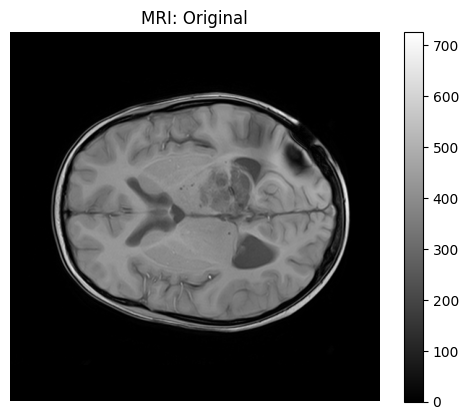

In [2]:
# open the image lab2_MRI.npy
img_mri = np.load("./input/lab2_MRI.npy")

# show the infromation of the image
print("Shape:", img_mri.shape)
print("Data type:", img_mri.dtype)
print("MAX value:", img_mri.max())
print("MIN value:", img_mri.min())

# show the image
plt.imshow(img_mri, cmap='gray')
plt.colorbar()
plt.title("MRI: Original")
plt.axis('off')
plt.show()

### 1.1 Forward-Backward Rotation

Rotate the image by pi/5, then rotate it back by -theta to its original position. Perform the above rotation with Nearest Neighbor and Bilinear interpolation.

In [3]:
def rotate_image_nearest(input_img, theta):
    """
    Rotate the image by theta using nearest neighbor interpolation.
    """

    # information of the image
    height, width = input_img.shape

    # transform matrix
    R = np.array([[np.cos(theta), -np.sin(theta), 0],
                  [np.sin(theta), np.cos(theta), 0],
                  [0, 0, 1]])
    T1 = np.array([[1, 0, -width / 2],
                   [0, 1, -height / 2],
                   [0, 0, 1]])
    T2 = np.array([[1, 0, width / 2],
                   [0, 1, height / 2],
                   [0, 0, 1]])
    T = T2 @ R @ T1

    # matrix of every pixel's coordinates
    x_i, y_i = np.meshgrid(np.arange(width), np.arange(height))
    coords = np.stack([x_i.ravel(), y_i.ravel(), np.ones(width * height)])

    # rotate the coordinates
    rotated_coords = np.dot(T, coords)

    # get (x, y) of the rotated coordinates
    x = rotated_coords[0, :].reshape(height, width)
    y = rotated_coords[1, :].reshape(height, width)

    # nearest neighbor interpolation
    x = np.round(x).astype(int)
    y = np.round(y).astype(int)

    # create the output image
    output_img = np.zeros_like(input_img)
    mask = (x >= 0) & (x < width) & (y >= 0) & (y < height)
    x_i, y_i = x_i.ravel()[mask.ravel()], y_i.ravel()[mask.ravel()]
    x, y = x.ravel()[mask.ravel()], y.ravel()[mask.ravel()]
    output_img[x_i, y_i] = input_img[x, y]

    return output_img

In [4]:
def rotate_image_bilinear(input_img, theta):
    """
    Rotate the image by theta using bilinear interpolation.
    """

    # information of the image
    height, width = input_img.shape
    
    # transform matrix
    R = np.array([[np.cos(theta), -np.sin(theta), 0],
                  [np.sin(theta), np.cos(theta), 0],
                  [0, 0, 1]])
    T1 = np.array([[1, 0, -width / 2],
                   [0, 1, -height / 2],
                   [0, 0, 1]])
    T2 = np.array([[1, 0, width / 2],
                   [0, 1, height / 2],
                   [0, 0, 1]])
    T = T2 @ R @ T1

    # matrix of every pixel's coordinates
    x_i, y_i = np.meshgrid(np.arange(width), np.arange(height))
    coords = np.stack([x_i.ravel(), y_i.ravel(), np.ones(width * height)])

    # rotate the coordinates
    rotated_coords = np.dot(T, coords)

    # get (x, y) of the rotated coordinates
    x = rotated_coords[0, :].reshape(height, width)
    y = rotated_coords[1, :].reshape(height, width)

    # bilinear interpolation
    x_floor, y_floor = np.floor(x).astype(int), np.floor(y).astype(int)
    x_ceil, y_ceil = np.ceil(x).astype(int), np.ceil(y).astype(int)
    dx, dy = x - x_floor, y - y_floor

    # check the coordinates are valid
    mask = (x_floor >= 0) & (x_ceil < width) & (y_floor >= 0) & (y_ceil < height)
    mask = mask.ravel()
    x_floor, y_floor = x_floor.ravel()[mask], y_floor.ravel()[mask]
    x_ceil, y_ceil = x_ceil.ravel()[mask], y_ceil.ravel()[mask]
    dx, dy = dx.ravel()[mask], dy.ravel()[mask]

    # create the output image
    output_img = np.zeros_like(input_img)
    output_img[y_i.ravel()[mask], x_i.ravel()[mask]] = \
        (1 - dx) * (1 - dy) * input_img[y_floor, x_floor] + \
        dx * (1 - dy) * input_img[y_floor, x_ceil] + \
        (1 - dx) * dy * input_img[y_ceil, x_floor] + \
        dx * dy * input_img[y_ceil, x_ceil]

    return output_img

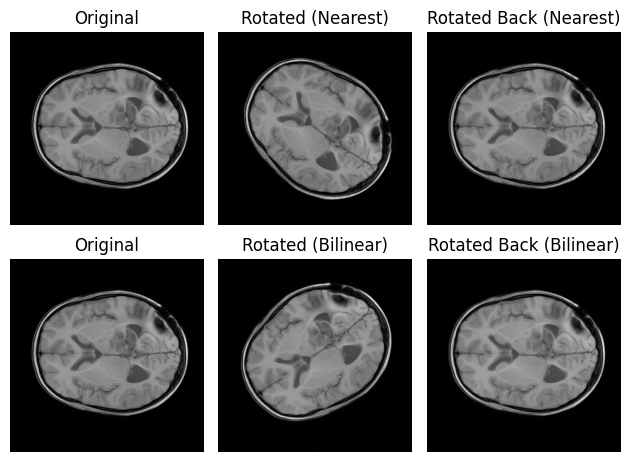

In [5]:
# parameters
theta = np.pi / 5

# rotate the image using nearest neighbor interpolation
img_mri_rotated_nearest = rotate_image_nearest(img_mri, theta)
img_mri_rotated_back_nearest = rotate_image_nearest(img_mri_rotated_nearest, -theta)

# rotate the image using bilinear interpolation
img_mri_rotated_bilinear = rotate_image_bilinear(img_mri, theta)
img_mri_rotated_back_bilinear = rotate_image_bilinear(img_mri_rotated_bilinear, -theta)

# show the all images
fig, axes = plt.subplots(2, 3)
axes[0, 0].imshow(img_mri, cmap='gray')
axes[0, 0].set_title("Original")
axes[0, 0].axis('off')
axes[0, 1].imshow(img_mri_rotated_nearest, cmap='gray')
axes[0, 1].set_title("Rotated (Nearest)")
axes[0, 1].axis('off')
axes[0, 2].imshow(img_mri_rotated_back_nearest, cmap='gray')
axes[0, 2].set_title("Rotated Back (Nearest)")
axes[0, 2].axis('off')
axes[1, 0].imshow(img_mri, cmap='gray')
axes[1, 0].set_title("Original")
axes[1, 0].axis('off')
axes[1, 1].imshow(img_mri_rotated_bilinear, cmap='gray')
axes[1, 1].set_title("Rotated (Bilinear)")
axes[1, 1].axis('off')
axes[1, 2].imshow(img_mri_rotated_back_bilinear, cmap='gray')
axes[1, 2].set_title("Rotated Back (Bilinear)")
axes[1, 2].axis('off')
fig.tight_layout()
plt.show()

### 1.2 Highlights the regions (zoom -in if needed) with notable differences between the two methods using arrows

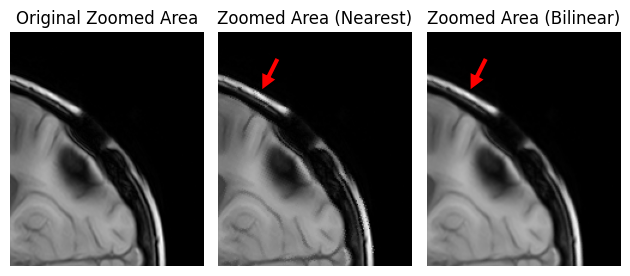

In [6]:
# information of the images
height, width = img_mri.shape
x, y = width // 3 * 2, height // 2

# select the area of the image
zoom_original = img_mri[60:y, x:width-10]
zoom_nn = img_mri_rotated_back_nearest[60:y, x:width-10]
zoom_bi = img_mri_rotated_back_bilinear[60:y, x:width-10]

# show the all images and check the difference between original and rotated back images
fig, axes = plt.subplots(1, 3)
axes[0].imshow(zoom_original, cmap='gray')
axes[0].set_title("Original Zoomed Area")
axes[0].axis('off')
axes[1].imshow(zoom_nn, cmap='gray')
axes[1].set_title("Zoomed Area (Nearest)")
axes[1].annotate('', xy=(35, 50), xytext=(50, 20),
             arrowprops=dict(facecolor='red', shrink=0.05))
axes[1].axis('off')
axes[2].imshow(zoom_bi, cmap='gray')
axes[2].set_title("Zoomed Area (Bilinear)")
axes[2].annotate('', xy=(35, 50), xytext=(50, 20),
             arrowprops=dict(facecolor='red', shrink=0.05))
axes[2].axis('off')
fig.tight_layout()
plt.show()


很明显，如果使用了最近邻逻辑（nearest neighbor）实现旋转，打上红色箭头的地方会有明显的锯齿状和马赛克感，而用双线性逻辑（bilinear）则没有，但是双线性逻辑旋转后的图像轮廓还是会有一定程度的模糊。

### 1.3 Show and quantify the differences between the original and the recovered image.

本部分主要采用了三个参数来实现对图像的量化：

1. MAE: 所有对应像素点之间差值的绝对平均值, 能反映出最基础的平均偏移量。
2. RMSE: 先将误差平方化, 再取平均并开方, 关注局部是否存在严重失真。
3. PSNR: 衡量的是信号的最大可能功率与噪声功率的比值, 提现了图像的整体质量。

In [7]:
def quantify_difference(original_img, recovered_img):
    """
    Quantify the difference between two images using Mean Squared Error (MSE).
    """

    # convert the images to float64
    original = original_img.astype(np.float64)
    recovered = recovered_img.astype(np.float64)

    # mae
    mae = np.mean(np.abs(original - recovered))

    # rmse
    mse = np.mean((original - recovered) ** 2)
    rmse = np.sqrt(mse)

    # psnr
    max_pixel = original.max()
    psnr = 20 * np.log10(max_pixel / rmse) if rmse != 0 else 100

    return mae, rmse, psnr


# test the function
mae_nn, rmse_nn, psnr_nn = quantify_difference(img_mri, img_mri_rotated_back_nearest)
mae_bi, rmse_bi, psnr_bi = quantify_difference(img_mri, img_mri_rotated_back_bilinear)

# print the quantification results
print(f"{'Metric':<10} | {'Nearest Neighbor':<20} | {'Bilinear':<20}")
print("-" * 55)
print(f"{'MAE':<10} | {mae_nn:<20.4f} | {mae_bi:<20.4f}")
print(f"{'RMSE':<10} | {rmse_nn:<20.4f} | {rmse_bi:<20.4f}")
print(f"{'PSNR (dB)':<10} | {psnr_nn:<20.4f} | {psnr_bi:<20.4f}")

Metric     | Nearest Neighbor     | Bilinear            
-------------------------------------------------------
MAE        | 1.3133               | 2.0964              
RMSE       | 9.9554               | 6.2469              
PSNR (dB)  | 37.2576              | 41.3054             


最近邻逻辑旋转得到的图像 MAE 值较小、整体失真更小，但是该图像在局部位置存在严重失真（也就是上面放大后看到的锯齿状边缘）。整体来看，通过比较 PSNR 值，认为双线性逻辑旋转得到的图像整体质量更高。

### 1.4 Compare the information loss between 1 rotation cycle (theta -> -theta) and 5 continuous rotation cycles

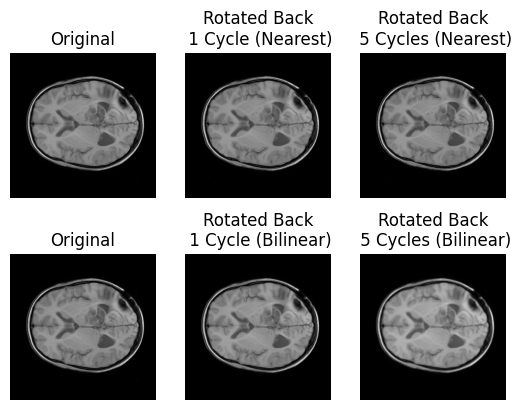

Metric     | Nearest (1 Cycle)    | Bilinear (1 Cycle)       | Nearest (5 Cycle)    | Bilinear (5 Cycle)   
------------------------------------------------------------------------------------------------------------------------
MAE        | 1.3133               | 2.0964                   | 1.3133               | 6.0401              
RMSE       | 9.9554               | 6.2469                   | 9.9554               | 17.1272             
PSNR (dB)  | 37.2576              | 41.3054                  | 37.2576              | 32.5450             


In [8]:
# copy the original image
img_mri_5cycle_nn = img_mri.copy()
img_mri_5cycle_bi = img_mri.copy()

# perform 5 circles
for i in range(5):

    # nearest neighbor
    img_mri_5cycle_nn = rotate_image_nearest(img_mri_5cycle_nn, theta)
    img_mri_5cycle_nn = rotate_image_nearest(img_mri_5cycle_nn, -theta)

    # bilinear
    img_mri_5cycle_bi = rotate_image_bilinear(img_mri_5cycle_bi, theta)
    img_mri_5cycle_bi = rotate_image_bilinear(img_mri_5cycle_bi, -theta)


# show the all images
fig, axes = plt.subplots(2, 3)
axes[0, 0].imshow(img_mri, cmap='gray')
axes[0, 0].set_title("Original")
axes[0, 0].axis('off')
axes[0, 1].imshow(img_mri_rotated_back_nearest, cmap='gray')
axes[0, 1].set_title("Rotated Back\n 1 Cycle (Nearest)")
axes[0, 1].axis('off')
axes[0, 2].imshow(img_mri_5cycle_nn, cmap='gray')
axes[0, 2].set_title("Rotated Back\n 5 Cycles (Nearest)")
axes[0, 2].axis('off')
axes[1, 0].imshow(img_mri, cmap='gray')
axes[1, 0].set_title("Original")
axes[1, 0].axis('off')
axes[1, 1].imshow(img_mri_rotated_back_bilinear, cmap='gray')
axes[1, 1].set_title("Rotated Back\n 1 Cycle (Bilinear)")
axes[1, 1].axis('off')
axes[1, 2].imshow(img_mri_5cycle_bi, cmap='gray')
axes[1, 2].set_title("Rotated Back\n 5 Cycles (Bilinear)")
axes[1, 2].axis('off')
# fig.tight_layout()
plt.show()


# test the function
mae_nn_5, rmse_nn_5, psnr_nn_5 = quantify_difference(img_mri, img_mri_5cycle_nn)
mae_bi_5, rmse_bi_5, psnr_bi_5 = quantify_difference(img_mri, img_mri_5cycle_bi)

# print the quantification results
print(f"{'Metric':<10} | {'Nearest (1 Cycle)':<20} | {'Bilinear (1 Cycle)':<20} \
    | {'Nearest (5 Cycle)':<20} | {'Bilinear (5 Cycle)':<20} ")
print("-" * 120)
print(f"{'MAE':<10} | {mae_nn:<20.4f} | {mae_bi:<20.4f} \
    | {mae_nn_5:<20.4f} | {mae_bi_5:<20.4f}")
print(f"{'RMSE':<10} | {rmse_nn:<20.4f} | {rmse_bi:<20.4f} \
    | {rmse_nn_5:<20.4f} | {rmse_bi_5:<20.4f}")
print(f"{'PSNR (dB)':<10} | {psnr_nn:<20.4f} | {psnr_bi:<20.4f} \
    | {psnr_nn_5:<20.4f} | {psnr_bi_5:<20.4f}")

通过对比以上图像和量化表格，可以发现：

双线性变换得到的图像在多次旋转后，图片质量持续下降，噪声越来越多。但是最近邻逻辑变换得到的图像质量与旋转次数没有直接关系，多次旋转得到的图像质量相同。

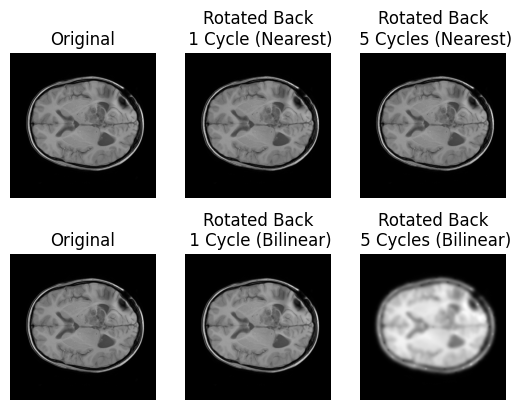

In [9]:
# copy the original image
img_mri_5cycle_nn = img_mri.copy()
img_mri_5cycle_bi = img_mri.copy()

# perform 5 circles
for i in range(100):

    # nearest neighbor
    img_mri_5cycle_nn = rotate_image_nearest(img_mri_5cycle_nn, theta)
    img_mri_5cycle_nn = rotate_image_nearest(img_mri_5cycle_nn, -theta)

    # bilinear
    img_mri_5cycle_bi = rotate_image_bilinear(img_mri_5cycle_bi, theta)
    img_mri_5cycle_bi = rotate_image_bilinear(img_mri_5cycle_bi, -theta)


# show the all images
fig, axes = plt.subplots(2, 3)
axes[0, 0].imshow(img_mri, cmap='gray')
axes[0, 0].set_title("Original")
axes[0, 0].axis('off')
axes[0, 1].imshow(img_mri_rotated_back_nearest, cmap='gray')
axes[0, 1].set_title("Rotated Back\n 1 Cycle (Nearest)")
axes[0, 1].axis('off')
axes[0, 2].imshow(img_mri_5cycle_nn, cmap='gray')
axes[0, 2].set_title("Rotated Back\n 5 Cycles (Nearest)")
axes[0, 2].axis('off')
axes[1, 0].imshow(img_mri, cmap='gray')
axes[1, 0].set_title("Original")
axes[1, 0].axis('off')
axes[1, 1].imshow(img_mri_rotated_back_bilinear, cmap='gray')
axes[1, 1].set_title("Rotated Back\n 1 Cycle (Bilinear)")
axes[1, 1].axis('off')
axes[1, 2].imshow(img_mri_5cycle_bi, cmap='gray')
axes[1, 2].set_title("Rotated Back\n 5 Cycles (Bilinear)")
axes[1, 2].axis('off')
# fig.tight_layout()
plt.show()

将旋转次数继续提高，提高到重复旋转 100 次。可以看到，双线性变换得到的图像已经严重模糊，但是最近邻逻辑得到的旋转图像的图像质量没有明显下降。

## Project 2: Intensity Transform

Shape: (512, 512)
Data type: uint8
MAX value: 255
MIN value: 0


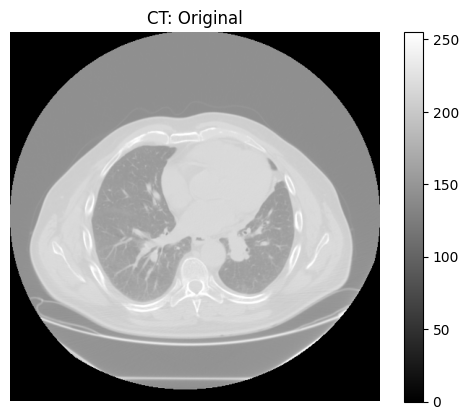

In [10]:
# open the image lab2_MRI.npy
img_ct = np.load("./input/lab2_CT.npy")

# show the infromation of the image
print("Shape:", img_ct.shape)
print("Data type:", img_ct.dtype)
print("MAX value:", img_ct.max())
print("MIN value:", img_ct.min())

# show the image
plt.imshow(img_ct, cmap='gray')
plt.colorbar()
plt.title("CT: Original")
plt.axis('off')
plt.show()

### 2.1 Adjust the parameters to achieve the best visual effect

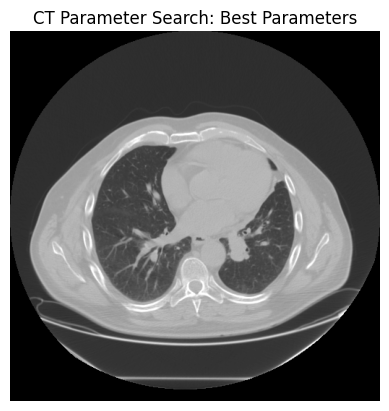

In [11]:
# original image parameters
img_ct_float = img_ct.astype(np.float32)
img_ct_norm = (img_ct_float - img_ct_float.min()) / (img_ct_float.max() - img_ct_float.min())

# parameters
gamma = 5.0
x0 = 0.75
alpha = (1 - 2 * x0 ** gamma) / (x0 ** (2 * gamma))

# transform
img_power = img_ct_norm ** gamma
img_power_float = img_power.astype(np.float32)
img_power_norm = (img_power_float - img_power_float.min()) / (img_power_float.max() - img_power_float.min())
img_log = np.log(1 + alpha * img_power_norm) / np.log(1 + alpha)

# show all images
fig = plt.figure()
plt.imshow(img_log, cmap='gray')
plt.title('CT Parameter Search: Best Parameters')
plt.axis('off')
plt.show()

选择最佳的参数是：

1. Power Transform: $\gamma = 5.0$
2. Log Transform: $\alpha = 9.33$

其中，$\alpha$ 和 $\gamma$ 满足以下等式：
$$
\alpha = f(\gamma) = \frac{1 - 2x_0^\gamma}{x_0^{2\gamma}}
$$

取 $x_0 = 0.75$.

### 2.2 Explain the major differences between the methods and parameters

1. Log Transform: $s = c \cdot \log(1 + \alpha \cdot r)$
2. Power Transform: $s = c \cdot r ^ {\gamma}$

两种变换都能根据参数的选择，拉伸图像的不同亮度的位置。但是对于 Log Transform ，$\alpha$ 越大，对暗部的拉伸越明显，暗部的对比度越大，暗部更有层次感；对于 Power Transform ，$\gamma$ 越大，对亮部的拉伸越明显，亮部的对比度越大，亮部更有层次感。

### 2.3 Explain how to select the optimal parameter
### 2.4 Design/select parameters that are appropriate forobserving lung tissue versus bone structures？

为了选择最优参数，先实现图像质量的评估。这里采用了信噪比 CNR 和直方图两种评估方法。

In [12]:
from skimage.filters import threshold_otsu

def quantify_cnr(input_image):
    """
    quantify the image according to CNR
    """

    # change the image to float32
    image = input_image.astype(np.float32)
    threshold = threshold_otsu(image)

    # get the target part (foreground) and backgroud
    foreground = image[image >= threshold]
    background = image[image < threshold]

    if foreground.size == 0 or background.size == 0:
        return 0.0

    mean_foreground = foreground.mean()
    mean_background = background.mean()
    std_foreground = foreground.std()
    std_background = background.std()

    cnr = np.abs(mean_foreground - mean_background) / np.sqrt(std_foreground ** 2 + std_background ** 2 + 1e-8)
    return cnr


def quantify_histogram(input_image):
    """
    quantify the image according to the histogram
    """

    # change the image to float32
    image = input_image.astype(np.float32)
    image_min = image.min()
    image_max = image.max()

    if image_max == image_min:
        output_image = np.zeros(256, dtype=np.float32)
        output_image[0] = 1.0
        return output_image

    # normalize the image 
    image_norm = (image - image_min) / (image_max - image_min)
    image_quantized = np.clip((image_norm * 255).astype(np.int32), 0, 255)

    output_image = np.bincount(image_quantized.ravel(), minlength=256).astype(np.float32)
    output_image = output_image / output_image.sum()
    return output_image

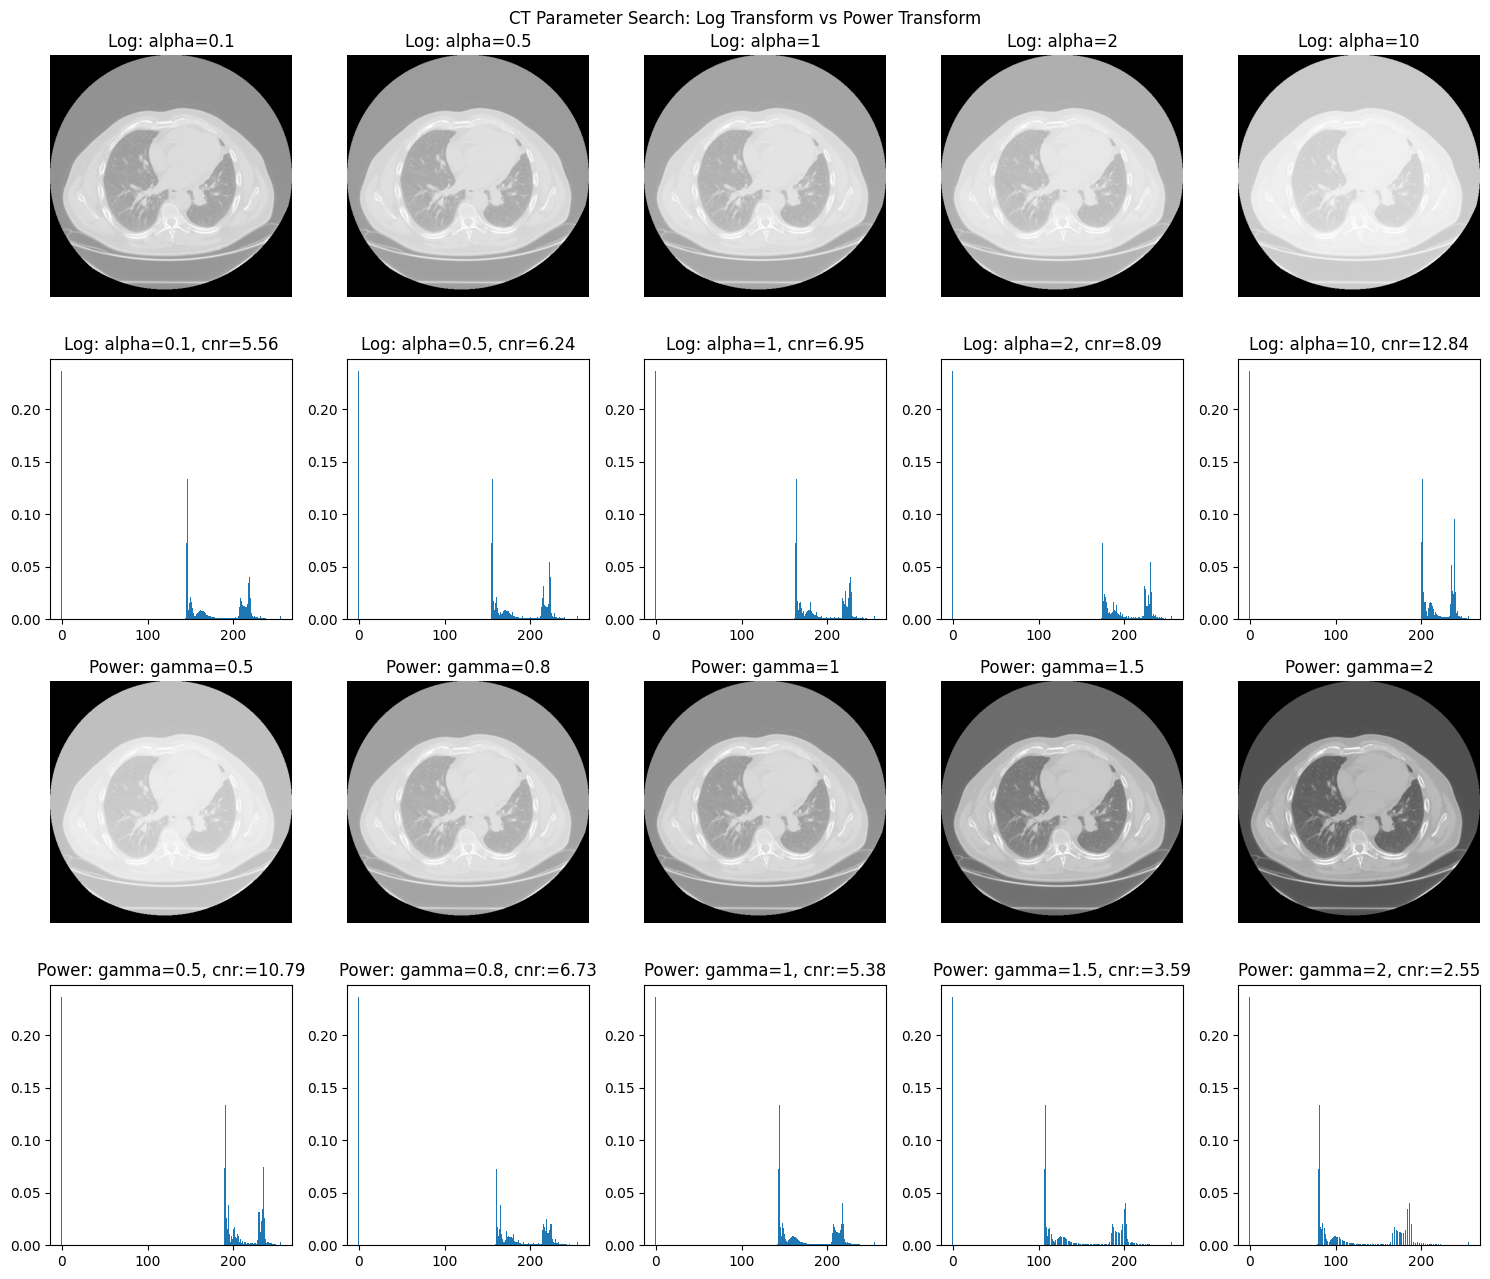

In [13]:
# change the image to float32 and normalize it
img_ct_float = img_ct.astype(np.float32)
img_ct_norm = (img_ct_float - img_ct_float.min()) / (img_ct_float.max() - img_ct_float.min())

# Use matrix operators on the whole image instead of pixel-wise loops
# Log transform: s = log(1 + alpha * r) / log(1 + alpha)
log_alphas = np.array([0.1, 0.5, 1, 2, 10], dtype=np.float32)

# Power transform: s = r ^ gamma
power_gammas = np.array([0.5, 0.8, 1, 1.5, 2.0], dtype=np.float32)

# show all images
fig, axes = plt.subplots(4, len(log_alphas), figsize=(3 * len(log_alphas), 13))
bins = np.arange(256)

for i, alpha in enumerate(log_alphas):
    img_log = np.log(1 + alpha * img_ct_norm) / np.log(1 + alpha)
    axes[0, i].imshow(img_log, cmap='gray')
    axes[0, i].set_title(f'Log: alpha={alpha:g}')
    axes[0, i].axis('off')
    img_log = np.log(1 + alpha * img_ct_norm) / np.log(1 + alpha)
    img_cnr = quantify_cnr(img_log)
    img_histogram = quantify_histogram(img_log)
    axes[1, i].bar(bins, img_histogram, width=1)
    axes[1, i].set_title(f'Log: alpha={alpha:g}, cnr={img_cnr:.2f}')

for i, gamma in enumerate(power_gammas):
    img_power = img_ct_norm ** gamma
    axes[2, i].imshow(img_power, cmap='gray')
    axes[2, i].set_title(f'Power: gamma={gamma:g}')
    axes[2, i].axis('off')
    img_power = img_ct_norm ** gamma
    img_cnr = quantify_cnr(img_power)
    img_histogram = quantify_histogram(img_power)
    axes[3, i].bar(bins, img_histogram, width=1)
    axes[3, i].set_title(f'Power: gamma={gamma:g}, cnr:={img_cnr:.2f}')

plt.suptitle('CT Parameter Search: Log Transform vs Power Transform')
plt.tight_layout()
plt.show()

根据直方图可以看出：目前的图像，信号强度都集中在亮部，暗部的强度很小，需要降低图像整体亮度。这里通过选取较大的 $\gamma$ 进行 Power Transform ，实现对暗部的压缩，让图像整体变暗。

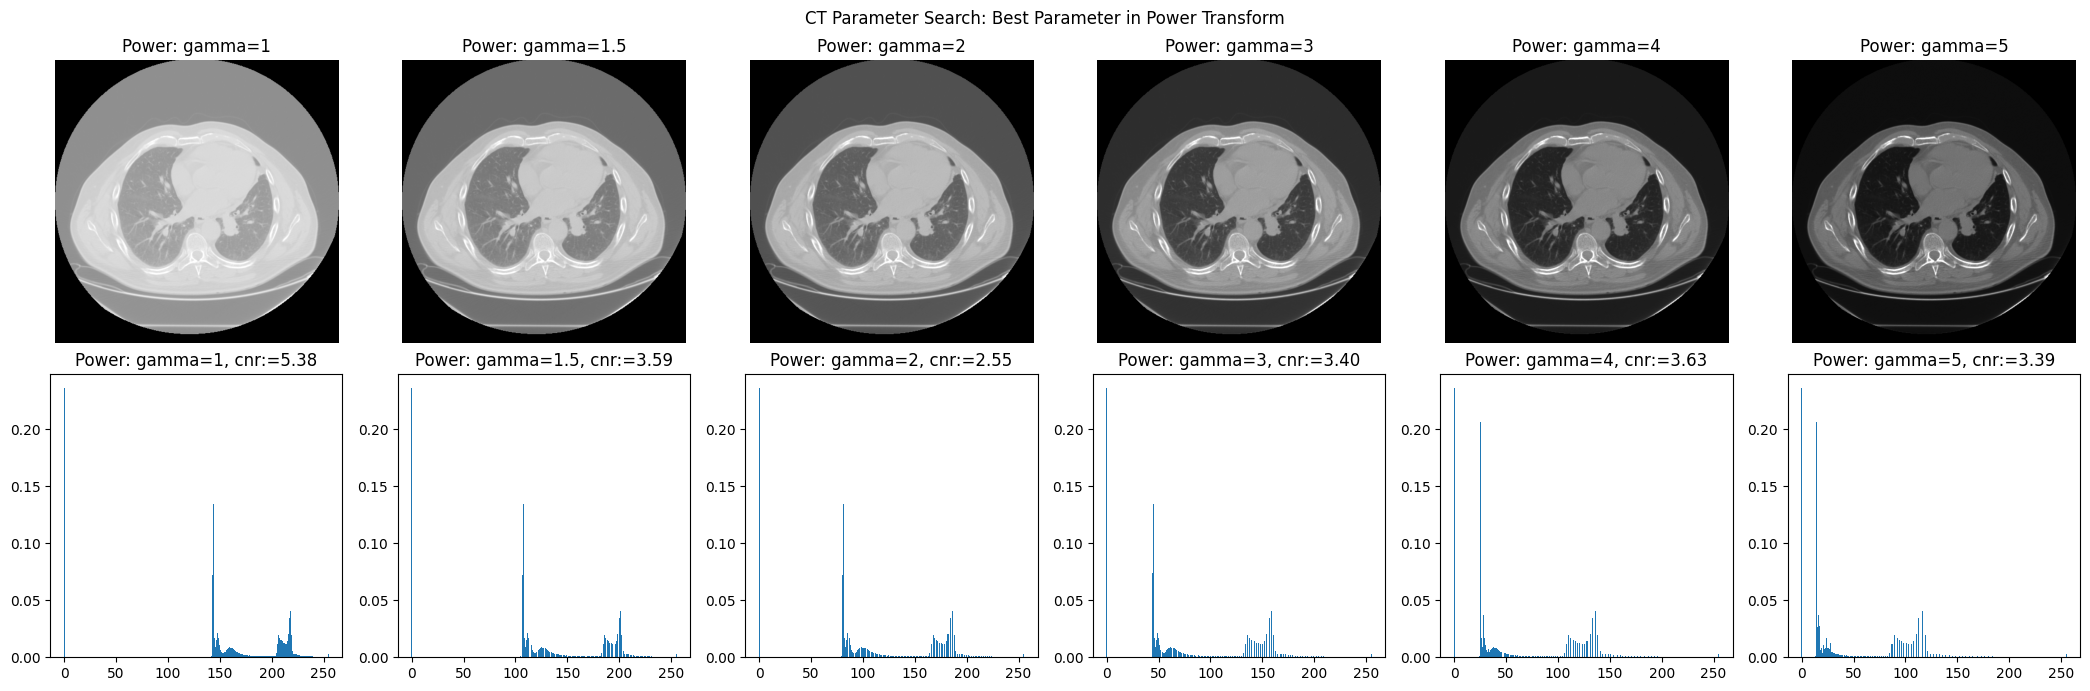

In [14]:
# Use matrix operators on the whole image instead of pixel-wise loops

# Power transform: s = r ^ gamma
power_gammas = np.array([1, 1.5, 2, 3, 4, 5], dtype=np.float32)

# show all images
fig, axes = plt.subplots(2, len(power_gammas), figsize=(3.5 * len(power_gammas), 7))

for i, gamma in enumerate(power_gammas):
    img_power = img_ct_norm ** gamma
    axes[0, i].imshow(img_power, cmap='gray')
    axes[0, i].set_title(f'Power: gamma={gamma:g}')
    axes[0, i].axis('off')
    img_cnr = quantify_cnr(img_power)
    img_histogram = quantify_histogram(img_power)
    axes[1, i].bar(bins, img_histogram, width=1)
    axes[1, i].set_title(f'Power: gamma={gamma:g}, cnr:={img_cnr:.2f}')

plt.suptitle('CT Parameter Search: Best Parameter in Power Transform')
plt.tight_layout()
plt.show()

发现对于 Power Transform ，选取 $\gamma = 4$ 的时候，肺部周围的气管末梢细节已经看不清了。因此，在选取参数 $\gamma$ 的时候，需要合理控制大小，在保持对比度的基础上保留尽可能多的细节。

进一步缩小参数选择范围到 gamma = 3 ~ 4 .

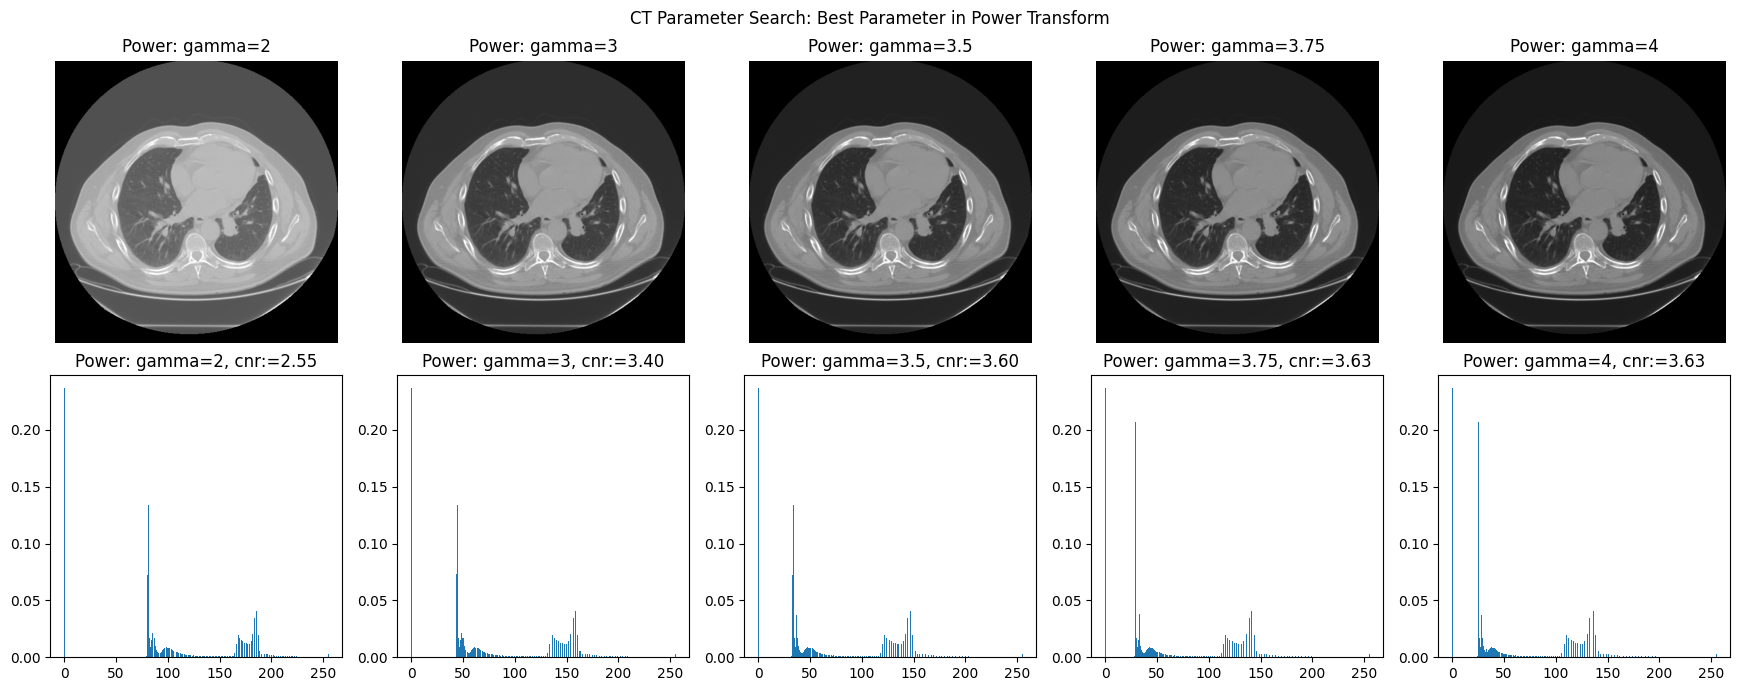

In [15]:
# Use matrix operators on the whole image instead of pixel-wise loops

# Power transform: s = r ^ gamma
power_gammas = np.array([2, 3, 3.5, 3.75, 4], dtype=np.float32)

# show all images
fig, axes = plt.subplots(2, len(power_gammas), figsize=(3.5 * len(power_gammas), 7))

for i, gamma in enumerate(power_gammas):
    img_power = img_ct_norm ** gamma
    axes[0, i].imshow(img_power, cmap='gray')
    axes[0, i].set_title(f'Power: gamma={gamma:g}')
    axes[0, i].axis('off')
    img_cnr = quantify_cnr(img_power)
    img_histogram = quantify_histogram(img_power)
    axes[1, i].bar(bins, img_histogram, width=1)
    axes[1, i].set_title(f'Power: gamma={gamma:g}, cnr:={img_cnr:.2f}')

plt.suptitle('CT Parameter Search: Best Parameter in Power Transform')
plt.tight_layout()
plt.show()

仅用 Power Transform 的情况下，参数 $\gamma$ 选择在 3 ~ 3.5 的范围内，能够同时加强图像并清晰观察到肺部组织。

可以在此基础上使用 Log Transform 对肺部组织进行进一步的清晰化。

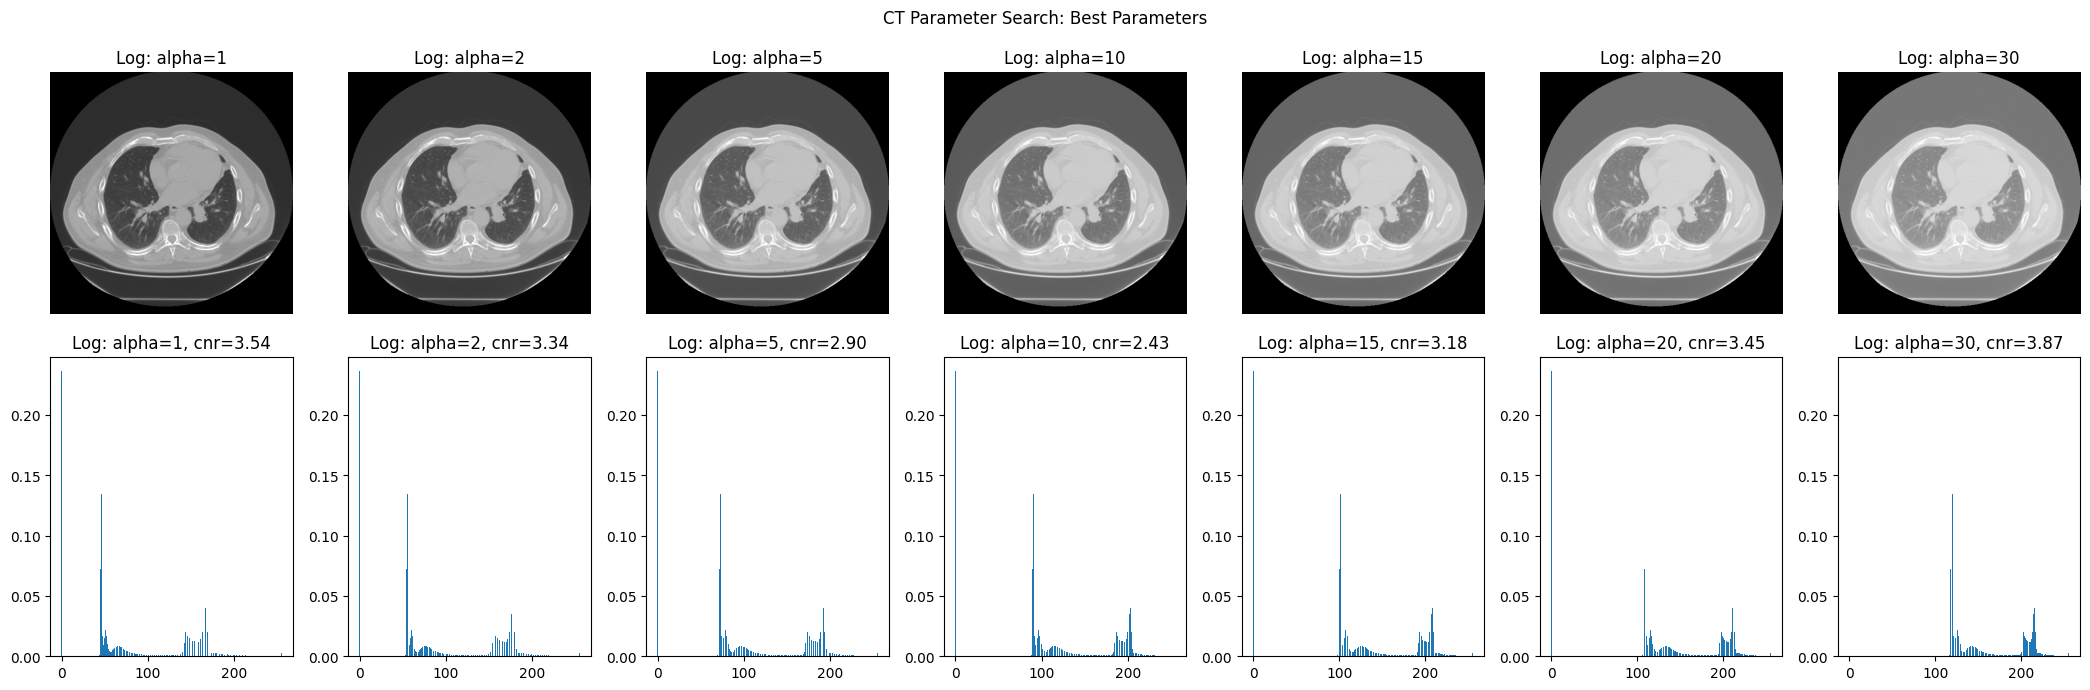

In [16]:
# original image parameters
img_ct_float = img_ct.astype(np.float32)
img_ct_norm = (img_ct_float - img_ct_float.min()) / (img_ct_float.max() - img_ct_float.min())

# select gamma = 3.5
gamma = 3.5
img_power = img_ct_norm ** gamma

# normalize the image performed power transform
img_power_float = img_power.astype(np.float32)
img_power_norm = (img_power_float - img_power_float.min()) / (img_power_float.max() - img_power_float.min())

# Use matrix operators on the whole image instead of pixel-wise loops
# Log transform: s = log(1 + alpha * r) / log(1 + alpha)
log_alphas = np.array([1, 2, 5, 10, 15, 20, 30], dtype=np.float32)

# show all images
fig, axes = plt.subplots(2, len(log_alphas), figsize=(3 * len(log_alphas), 7))

for i, alpha in enumerate(log_alphas):
    img_log = np.log(1 + alpha * img_power_norm) / np.log(1 + alpha)
    axes[0, i].imshow(img_log, cmap='gray')
    axes[0, i].set_title(f'Log: alpha={alpha:g}')
    axes[0, i].axis('off')
    img_cnr = quantify_cnr(img_log)
    img_histogram = quantify_histogram(img_log)
    axes[1, i].bar(bins, img_histogram, width=1)
    axes[1, i].set_title(f'Log: alpha={alpha:g}, cnr={img_cnr:.2f}')

plt.suptitle('CT Parameter Search: Best Parameters')
plt.tight_layout()
plt.show()

认为在 $\gamma = 3.5$ 的情况下，选择 $\alpha = 2 \sim 5$ 进行 log transform 获得的图像视觉效果较好。

我们对以上方法进行数学推导：

$$
T(x) = \frac{\log(1 + \alpha \cdot x ^ \gamma)}{\log(1 + \alpha)}
$$

假设某个亮度经过以上变换后，亮度不变，即：

$$
T(x_0) = C
$$

化简后可以得到：

$$
\alpha = \frac{1 - 2x_0^\gamma}{x_0^{2\gamma}}
$$

只要选取 $x_0$ 为骨骼和肺组织的分界点即可。

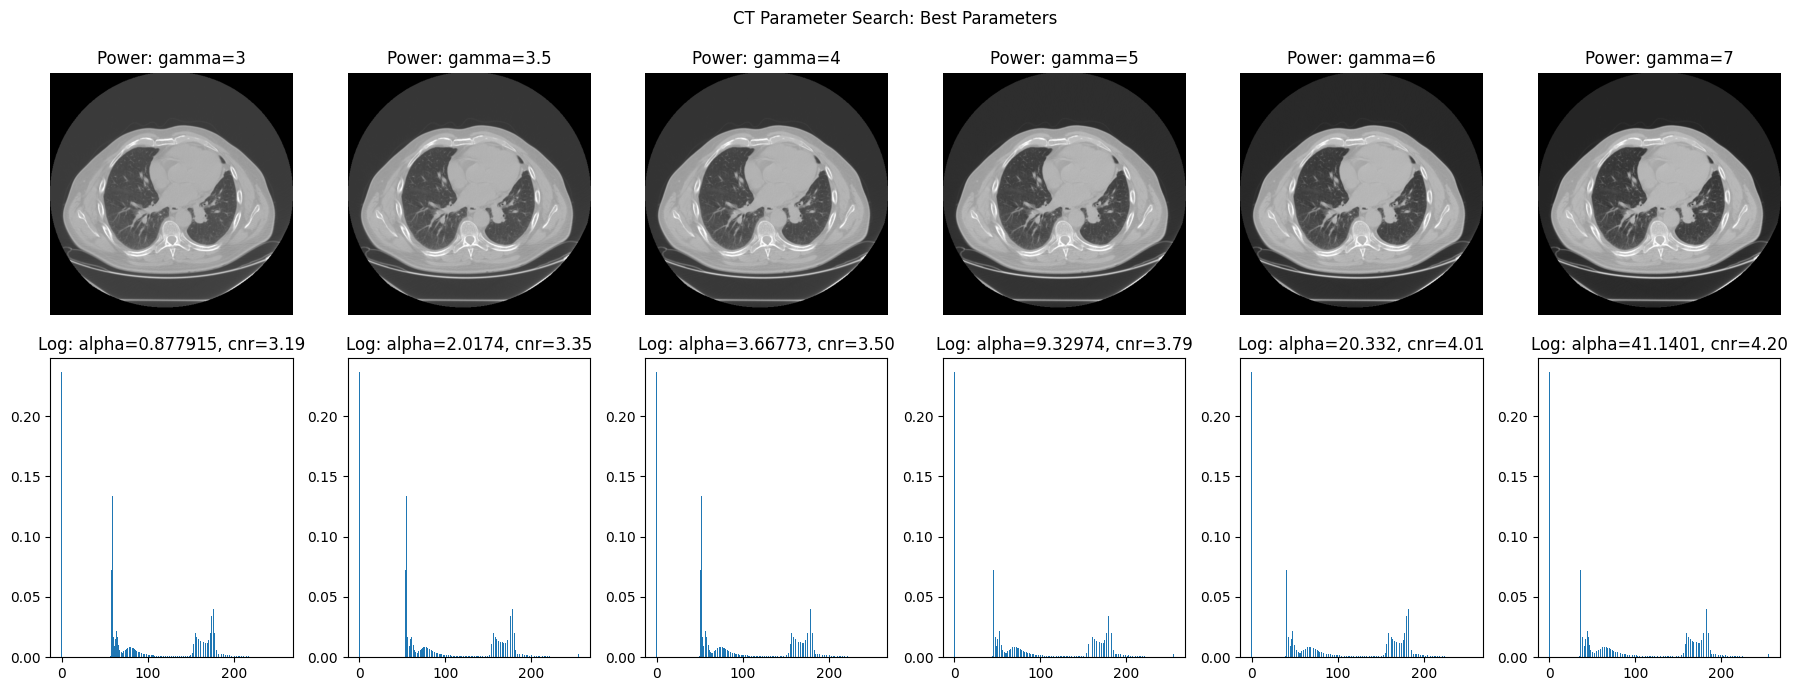

In [17]:
# original image parameters
img_ct_float = img_ct.astype(np.float32)
img_ct_norm = (img_ct_float - img_ct_float.min()) / (img_ct_float.max() - img_ct_float.min())

# Power transform: s = r ^ gamma
power_gammas = np.array([3.0, 3.5, 4.0, 5.0, 6.0, 7.0], dtype=np.float32)

# show all images
fig, axes = plt.subplots(2, len(power_gammas), figsize=(3 * len(power_gammas), 7))
x0 = 0.75

for i, gamma in enumerate(power_gammas):
    img_power = img_ct_norm ** gamma
    img_power_float = img_power.astype(np.float32)
    img_power_norm = (img_power_float - img_power_float.min()) / (img_power_float.max() - img_power_float.min())
    alpha = (1 - 2 * x0 ** gamma) / (x0 ** (2 * gamma))
    img_log = np.log(1 + alpha * img_power_norm) / np.log(1 + alpha)
    axes[0, i].imshow(img_log, cmap='gray')
    axes[0, i].set_title(f'Power: gamma={gamma:g}')
    axes[0, i].axis('off')
    img_cnr = quantify_cnr(img_log)
    img_histogram = quantify_histogram(img_log)
    axes[1, i].bar(bins, img_histogram, width=1)
    axes[1, i].set_title(f'Log: alpha={alpha:g}, cnr={img_cnr:.2f}')

plt.suptitle('CT Parameter Search: Best Parameters')
plt.tight_layout()
plt.show()

选取 $x_0 = 0.75$ 的时候，得到的图像的直方图都能够尽可能铺满整个轴，并且信噪比 CNR 也在 $3 \sim 4$ 左右。在其中选择第四组认为是视觉效果最好的，也就是先采用 $\gamma = 5$ 的 Power Transform 再采用 $\alpha = 9.33$ 的 Log Transform 得到的效果最好。

## Project 3: Spatial Filter: High pass filter

Shape: (747, 470, 4)
Data type: uint8
MAX value: 255
MIN value: 0


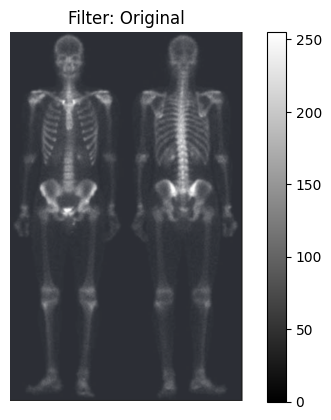

In [18]:
# open the image lab2_MRI.npy
img_filter = np.load("./input/lab2_filter.npy")

# show the infromation of the image
print("Shape:", img_filter.shape)
print("Data type:", img_filter.dtype)
print("MAX value:", img_filter.max())
print("MIN value:", img_filter.min())

# show the image
plt.imshow(img_filter, cmap='gray')
plt.colorbar()
plt.title("Filter: Original")
plt.axis('off')
plt.show()

先实现一些必须的滤波器函数和转换函数。

在此基础上，在实验中还希望实现对中间亮度的伸展，因此额外设计了 Sigmoid Transform 函数。

In [19]:
def LaplacianFilter(input_img, neighbor: int = 8):
    """
    8-neighbor Laplacian filter
    """

    # change the image to float32
    if input_img.ndim == 3:
        img = (0.299 * input_img[:, :, 0] + 
               0.587 * input_img[:, :, 1] + 
               0.114 * input_img[:, :, 2])
    else:
        img = input_img
    img = np.asarray(img, dtype=np.float32)

    # get the kernel
    if neighbor == 4:
        kernel = np.array([[0, -1, 0],
                           [-1, 4, -1],
                           [0, -1, 0]], dtype=np.float32)
    elif neighbor == 8:
        kernel = np.array([[-1, -1, -1],
                           [-1, 8, -1],
                           [-1, -1, -1]], dtype=np.float32)
    else:
        kernel = np.array([[-1, -1, -1],
                           [-1, 8, -1],
                           [-1, -1, -1]], dtype=np.float32)

    # padding the edge of image
    padded = np.pad(img, ((1, 1), (1, 1)), mode='edge')
    output_img = np.zeros_like(img, dtype=np.float32)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i + 3, j:j + 3]
            output_img[i, j] = np.sum(region * kernel)

    # Organizing the output image
    # output_img = np.abs(output_img)
    # output_img = output_img - output_img.min()
    print(f"Mask range of Laplacian Image: {output_img.min()} to {output_img.max()}")
    output_img_norm = \
        (output_img - output_img.min()) / (output_img.max() - output_img.min())
    output_img_int = np.clip(output_img_norm * 255, 0, 255).astype(np.uint8)


    return output_img, output_img_norm, output_img_int



def SobelFilter(input_img, kernel: int = 3, directtions: int = 2, threshold: float = None):
    """
    3 * 3 Sobel filter in 2 directions
    """

    # check the parameters
    if kernel != 3 or directtions != 2:
        raise ValueError("This function only supports 3x3 Sobel filter in 2 directions")

    # change the image to float32
    if input_img.ndim == 3:
        img = (0.299 * input_img[:, :, 0] + 
               0.587 * input_img[:, :, 1] + 
               0.114 * input_img[:, :, 2])
    else:
        img = input_img
    img = np.asarray(img, dtype=np.float32)

    # get the kernel
    sobel_x = np.array([[-1, 0, 1],
                        [-2, 0, 2],
                        [-1, 0, 1]], dtype=np.float32)
    sobel_y = np.array([[-1, -2, -1],
                        [0, 0, 0],
                        [1, 2, 1]], dtype=np.float32)
    
    # padding the edge of the image
    padded = np.pad(img, ((1, 1), (1, 1)), mode='edge')
    grad_x = np.zeros_like(img, dtype=np.float32)
    grad_y = np.zeros_like(img, dtype=np.float32)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i + 3, j:j + 3]
            grad_x[i, j] = np.sum(region * sobel_x)
            grad_y[i, j] = np.sum(region * sobel_y)

    output_img = np.sqrt(grad_x ** 2 + grad_y ** 2)
    print(f"Mask range of Sobel Image: {output_img.min()} to {output_img.max()}")

    if threshold is not None:
        output_img[output_img < threshold] = 0

    output_img_norm = \
        (output_img - output_img.min()) / (output_img.max() - output_img.min())
    output_img_int = np.clip(output_img_norm * 255, 0, 255).astype(np.uint8)

    return output_img, output_img_norm, output_img_int



def BoxFilter(input_img, kernel: int = 3):
    """
    Box filter of the image 
    """

    # check the parameter
    if kernel % 2 == 0 or kernel < 1:
        raise ValueError("kernel size must be a positive odd number")

    # change the image to float32
    if input_img.ndim == 3:
        img = (0.299 * input_img[:, :, 0] + 
               0.587 * input_img[:, :, 1] + 
               0.114 * input_img[:, :, 2])
    else:
        img = input_img
    img = np.asarray(img, dtype=np.float32)

    # padding the image
    pad = kernel // 2
    padded = np.pad(img, ((pad, pad), (pad, pad)), mode='edge')
    output_img = np.zeros_like(img, dtype=np.float32)
    box_kernel = np.ones((kernel, kernel), dtype=np.float32) / (kernel * kernel)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i + kernel, j:j + kernel]
            output_img[i, j] = np.sum(region * box_kernel)

    print(f"Mask range of Box Image: {output_img.min()} to {output_img.max()}")
    output_img_norm = \
        (output_img - output_img.min()) / (output_img.max() - output_img.min())
    output_img_int = np.clip(output_img_norm * 255, 0, 255).astype(np.uint8)

    return output_img, output_img_norm, output_img_int



def MedianFilter(input_img, kernal: int = 3):
    """
    Median Filter of input image
    """

    # check the parameter
    if kernal % 2 == 0 or kernal < 1:
        raise ValueError("kernal size must be a positive odd number")

    # change the image to float32
    if input_img.ndim == 3:
        img = (0.299 * input_img[:, :, 0] + 
               0.587 * input_img[:, :, 1] + 
               0.114 * input_img[:, :, 2])
    else:
        img = input_img
    img = np.asarray(img, dtype=np.float32)

    # padding the image
    pad = kernal // 2
    padded = np.pad(img, ((pad, pad), (pad, pad)), mode='edge')
    output_img = np.zeros_like(img, dtype=np.float32)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i + kernal, j:j + kernal]
            output_img[i, j] = np.median(region)

    print(f"Mask range of Median Image: {output_img.min()} to {output_img.max()}")
    output_img_norm = \
        (output_img - output_img.min()) / (output_img.max() - output_img.min())
    output_img_int = np.clip(output_img_norm * 255, 0, 255).astype(np.uint8)

    return output_img, output_img_norm, output_img_int



def SharpenMask(img_laplacian, img_sobel_box):
    img_sobel_box_norm = \
        (img_sobel_box - img_sobel_box.min()) / (img_sobel_box.max() - img_sobel_box.min())
    output_img = img_laplacian * img_sobel_box_norm
    print(f"Mask range of Sharpen Mask: {output_img.min()} to {output_img.max()}")
    output_img_norm = \
        (output_img - output_img.min()) / (output_img.max() - output_img.min())
    output_img_int = np.clip(output_img_norm * 255, 0, 255).astype(np.uint8)

    return output_img, output_img_norm, output_img_int


def SharpenEnhence(img_original, img_mask, k: float = 1.0):
    output_img = img_original + img_mask * k
    print(f"Mask range of Sharpen Image: {output_img.min()} to {output_img.max()}")
    output_img_norm = \
        (output_img - output_img.min()) / (output_img.max() - output_img.min())
    output_img_int = np.clip(output_img_norm * 255, 0, 255).astype(np.uint8)

    return output_img, output_img_norm, output_img_int


def PowerTransform(input_img, gamma):
    input_img_norm = \
        (input_img - input_img.min()) / (input_img.max() - input_img.min())
    output_img_norm = np.power(input_img_norm, gamma)
    output_img = output_img_norm * 255
    print(f"Mask range of Power Transform: {output_img.min()} to {output_img.max()}")
    output_img_int = np.clip(output_img, 0, 255).astype(np.uint8)

    return output_img, output_img_norm, output_img_int

def LogTransform(input_img, alpha):
    input_img_norm = \
        (input_img - input_img.min()) / (input_img.max() - input_img.min())
    output_img_norm = np.log(1 + alpha * input_img_norm) / np.log(1 + alpha)
    output_img = output_img_norm * 255
    print(f"Mask range of Log Transform: {output_img.min()} to {output_img.max()}")
    output_img_int = np.clip(output_img, 0, 255).astype(np.uint8)

    return output_img, output_img_norm, output_img_int


def SigmoidTransform(input_img, alpha: float = 10.0, beta: float = 0.5):
    input_img_norm = \
        (input_img - input_img.min()) / (input_img.max() - input_img.min())
    output_img_norm = 1 / (1 + np.exp(-alpha * (input_img_norm - beta)))
    output_img = output_img_norm * 255
    output_img_int = np.clip(output_img, 0, 255).astype(np.uint8)

    return output_img, output_img_norm, output_img_int


Mask range of Median Image: 0.0 to 254.0
Mask range of Laplacian Image: -110.0 to 124.0
Mask range of Sharpen Image: -110.0 to 353.06695556640625
Mask range of Sobel Image: 0.0 to 313.3594665527344
Mask range of Box Image: 0.0 to 269.7984619140625
Mask range of Sharpen Mask: 0.0 to 244.1913299560547
Mask range of Sharpen Image: 33.45170974731445 to 714.4966430664062
Mask range of Power Transform: 0.0 to 255.0
Mask range of Log Transform: 0.0 to 254.9999943314106


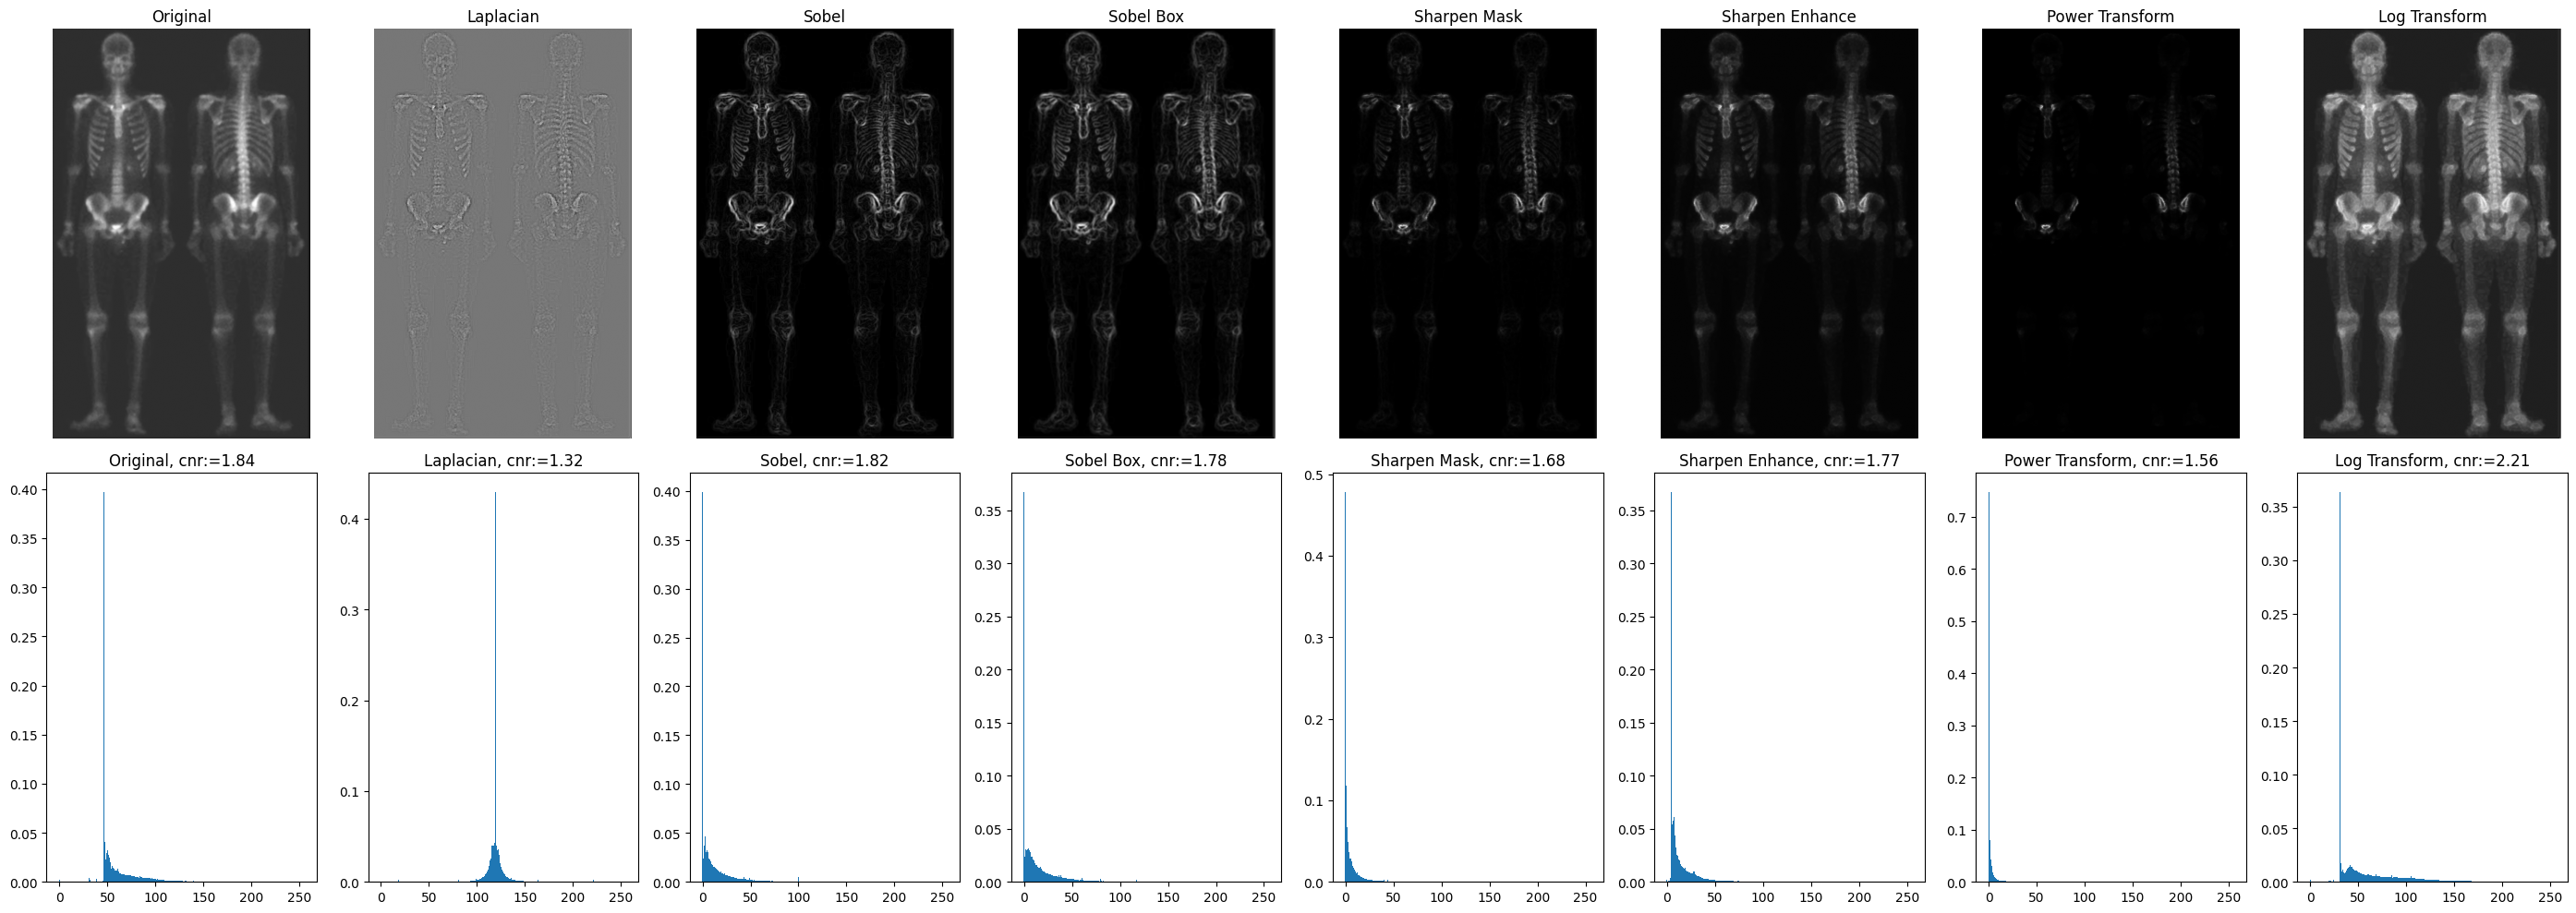

In [20]:
# test
kernel_size = 3
k = 2
gamma = 2
x0 = 0.4
alpha = (1 - 2 * x0 ** gamma) / (x0 ** (2 * gamma))

# transform
img_filter_median, img_filter_median_norm, img_filter_median_int = MedianFilter(img_filter)
img_filter_laplacian, img_filter_laplacian_norm, img_filter_laplacian_int = LaplacianFilter(img_filter_median)
img_laplacian, img_laplacian_norm, img_laplacian_int = SharpenEnhence(img_filter_median, img_filter_laplacian)
img_filter_sobel, img_filter_sobel_norm, img_filter_sobel_int = SobelFilter(img_filter_median)
img_filter_sobel_box, img_filter_sobel_box_norm, img_filter_sobel_box_int = BoxFilter(img_filter_sobel, kernel=kernel_size)
img_sharpen_mask, img_sharpen_mask_norm, img_sharpen_mask_int = SharpenMask(np.abs(img_laplacian), img_filter_sobel_box)
img_sharpen, img_sharpen_norm, img_sharpen_int = SharpenEnhence(img_filter_median, img_sharpen_mask, k=k)
img_power, img_power_norm, img_power_int = PowerTransform(img_sharpen, gamma)
img_log, img_log_norm, img_log_int = LogTransform(img_sharpen, alpha)

img_list = [
    img_filter_median_int,
    img_filter_laplacian_int,
    img_filter_sobel_int,
    img_filter_sobel_box_int,
    img_sharpen_mask_int,
    img_sharpen_int,
    img_power_int,
    img_log_int,
]
title_list = [
    "Original",
    "Laplacian",
    "Sobel",
    "Sobel Box",
    "Sharpen Mask",
    "Sharpen Enhance",
    "Power Transform",
    "Log Transform",
]

fig, axes = plt.subplots(2, len(img_list), figsize=(3.5 * len(img_list), 10))

for i, img in enumerate(img_list):
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f'{title_list[i]}')
    axes[0, i].axis('off')
    img_cnr = quantify_cnr(img)
    img_histogram = quantify_histogram(img)
    axes[1, i].bar(bins, img_histogram, width=1)
    axes[1, i].set_title(f'{title_list[i]}, cnr:={img_cnr:.2f}')

plt.tight_layout()
plt.show()

最后的增强成果如下图所示

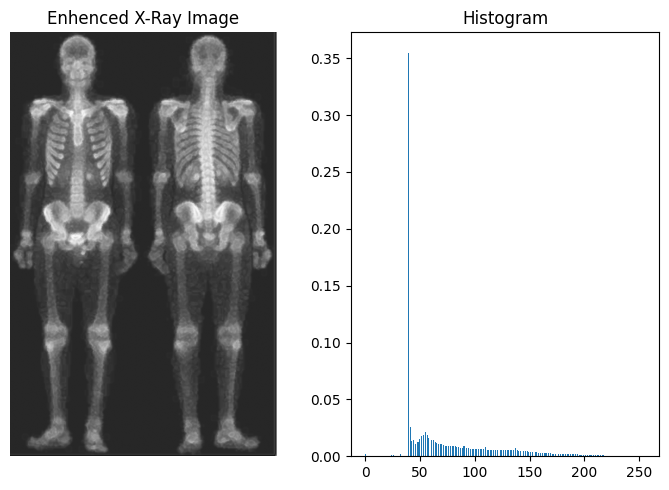

In [21]:
img_sig, img_sig_norm, img_sig_int = SigmoidTransform(img_log, alpha=3, beta=0.2)
img = img_sig_int

# show the images
fig, axes = plt.subplots(1, 2, figsize=(7, 5))

axes[0].imshow(img, cmap="grey")
axes[0].set_title("Enhenced X-Ray Image")
axes[0].axis("off")
img_histogram = quantify_histogram(img)
axes[1].bar(bins, img_histogram, width=1)
axes[1].set_title("Histogram")

plt.tight_layout()
plt.show()